Loaded: vocab=50,000, merges=49,799, prefix='', add_prefix_space=True, byte_fallback=True
Tracking token='Ġth' (id=203) from k=3 to k=23 over corpus='/Users/ahmetcanyavuz/Developer/tokenizers/fineweb_data/fineweb_en_sentences.txt'
Corpus limit: None lines, batch_size=1000000


Counting across steps:   0%|          | 0/21 [00:00<?, ?it/s]

built tokenizer with k= 3


Counting across steps:   5%|▍         | 1/21 [01:54<38:17, 114.87s/it]

count for k= 3 is 7618630
built tokenizer with k= 4


...

count for k= 21 is 2052678
built tokenizer with k= 22


Counting across steps:  95%|█████████▌| 20/21 [35:12<01:46, 106.04s/it]

count for k= 22 is 2052678
built tokenizer with k= 23


Counting across steps: 100%|██████████| 21/21 [36:53<00:00, 105.42s/it]

count for k= 23 is 2052678
Done in 2213.8s. Measured 21 steps.


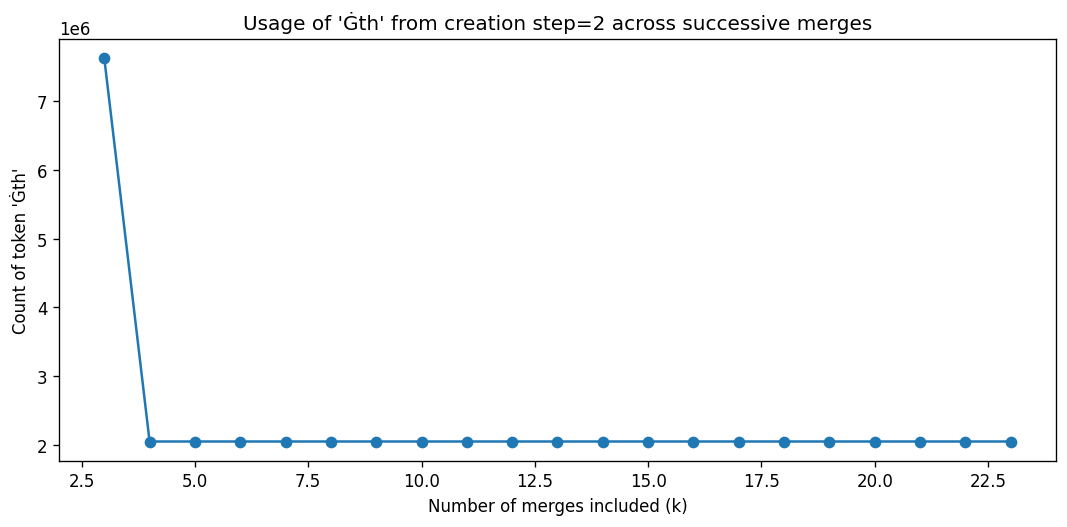

k=      3 → count=7618630
k=      4 → count=2052678
k=      5 → count=2052678
k=      6 → count=2052678
k=      7 → count=2052678
k=      8 → count=2052678
k=      9 → count=2052678
k=     10 → count=2052678
k=     11 → count=2052678
k=     12 → count=2052678
...
k=     19 → count=2052678
k=     20 → count=2052678
k=     21 → count=2052678
k=     22 → count=2052678
k=     23 → count=2052678


In [11]:
import json, os, time
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Iterable

TOKENIZER_JSON = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_exact_ll/bpe_exact_ll-tokenizer.json"
CORPUS_PATH    = "/Users/ahmetcanyavuz/Developer/tokenizers/fineweb_data/fineweb_en_sentences.txt"

# Token string to track (exact string as in vocab; for byte-level models many tokens begin with 'Ġ')
TOKEN_TO_TRACK = "Ġth"       # e.g. "stances", "umstances", or "Ġthe"

# How far to continue counting past the token's creation step
NUM_STEPS_AFTER_CREATION = 20     # None = all remaining merges (slower)

# Limit corpus read for speed (None = all)
MAX_LINES  = None
BATCH_SIZE = 1000000


from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel as ByteLevelPre
from tokenizers.decoders import ByteLevel as ByteLevelDec
import matplotlib.pyplot as plt
from tqdm import tqdm

def load_bpe_from_tokenizer_json(tok_json_path: str):
    """
    Return (vocab, merges, continuing_subword_prefix, byte_fallback, add_prefix_space, end_of_word_suffix).
    Handles merges as either ["a b", ...] or [["a","b"], ...].
    """
    data = json.loads(Path(tok_json_path).read_text())
    m = data.get("model", {})
    if (m.get("type") or "").upper() != "BPE":
        raise SystemExit(f"❌ Expected a BPE tokenizer.json, got type={m.get('type')!r}")

    # vocab may be dict or list of [token, id]
    v_raw = m.get("vocab")
    if isinstance(v_raw, dict):
        vocab = {str(k): int(v) for k, v in v_raw.items()}
    elif isinstance(v_raw, list):
        vocab = {str(k): int(v) for (k, v) in v_raw}
    else:
        raise SystemExit("❌ Unsupported model.vocab format in tokenizer.json")

    # merges can be ["a b", ...] OR [["a","b"], ...]
    merges_field = m.get("merges") or []
    merges: List[Tuple[str, str]] = []
    for ent in merges_field:
        if isinstance(ent, str):
            parts = ent.split()
            if len(parts) == 2:
                merges.append((parts[0], parts[1]))
        elif isinstance(ent, list) and len(ent) == 2:
            merges.append((str(ent[0]), str(ent[1])))

    prefix = m.get("continuing_subword_prefix") or ""
    byte_fallback = bool(m.get("byte_fallback", False))
    end_of_word_suffix = m.get("end_of_word_suffix")

    # Find ByteLevel.add_prefix_space from pre_tokenizer
    def scan_for_bytelevel(node) -> Optional[bool]:
        if isinstance(node, dict):
            t = node.get("type")
            if t == "ByteLevel":
                return bool(node.get("add_prefix_space", False))
            if t == "Sequence":
                for sub in node.get("pretokenizers", []):
                    x = scan_for_bytelevel(sub)
                    if x is not None:
                        return x
        elif isinstance(node, list):
            for sub in node:
                x = scan_for_bytelevel(sub)
                if x is not None:
                    return x
        return None
    add_prefix_space = bool(scan_for_bytelevel(data.get("pre_tokenizer")) or False)

    return vocab, merges, prefix, byte_fallback, add_prefix_space, end_of_word_suffix

def resolve_token_string(requested: str, vocab: Dict[str,int], prefix: str) -> str:
    """
    Return the exact vocab key we will count.
    Tries the requested string as-is, then tries prefix+requested if a continuing_subword_prefix is set.
    """
    if requested in vocab:
        return requested
    if prefix and (prefix + requested) in vocab:
        print(f"ℹ️  Using '{prefix + requested}' for requested '{requested}' (continuing_subword_prefix).")
        return prefix + requested
    raise SystemExit(f"❌ Token '{requested}' not found in vocab "
                     f"(also tried '{prefix + requested}' if prefix exists).")

def find_creation_step(merges: List[Tuple[str,str]], token: str, prefix: str) -> Optional[int]:
    """
    Reproduce how new token is formed during training:
      new_token = a + b[prefix_len:] if b starts with continuing_subword_prefix else a + b
    """
    plen = len(prefix) if prefix else 0
    for i, (a, b) in enumerate(merges):
        new_tok = a + (b[plen:] if (plen and b.startswith(prefix)) else b)
        if new_tok == token:
            return i
    return None

def build_tokenizer_with_k_merges(
    vocab: Dict[str,int],
    merges: List[Tuple[str,str]],
    k: int,
    *,
    byte_fallback: bool,
    prefix: str,
    add_prefix_space: bool,
    end_of_word_suffix: Optional[str],
) -> Tokenizer:
    k = max(0, min(k, len(merges)))
    # IMPORTANT: only pass these kwargs if set (bindings expect strings, not None)
    kwargs = dict(vocab=vocab, merges=merges[:k], byte_fallback=byte_fallback)
    if prefix:
        kwargs["continuing_subword_prefix"] = prefix
    if end_of_word_suffix:
        kwargs["end_of_word_suffix"] = end_of_word_suffix

    model = BPE(**kwargs)
    tok = Tokenizer(model)
    tok.pre_tokenizer = ByteLevelPre(add_prefix_space=bool(add_prefix_space))
    tok.decoder = ByteLevelDec()
    return tok

def iter_lines(path: str, limit: Optional[int] = None) -> Iterable[str]:
    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.rstrip("\n")
            if not s: 
                continue
            yield s
            n += 1
            if limit is not None and n >= limit:
                break

def count_token_in_corpus(tok: Tokenizer, target_id: int, path: str, *, max_lines: Optional[int], batch_size: int) -> int:
    total = 0
    batch: List[str] = []
    for s in iter_lines(path, limit=max_lines):
        batch.append(s)
        if len(batch) >= batch_size:
            encs = tok.encode_batch(batch, add_special_tokens=False)
            for e in encs:
                total += sum(1 for tid in e.ids if tid == target_id)
            batch.clear()
    if batch:
        encs = tok.encode_batch(batch, add_special_tokens=False)
        for e in encs:
            total += sum(1 for tid in e.ids if tid == target_id)
    return total


t0 = time.time()
vocab, merges, prefix, byte_fallback, add_prefix_space, eow_suffix = load_bpe_from_tokenizer_json(TOKENIZER_JSON)
print(f"Loaded: vocab={len(vocab):,}, merges={len(merges):,}, prefix={prefix!r}, add_prefix_space={add_prefix_space}, byte_fallback={byte_fallback}")

if not merges:
    raise SystemExit("❌ No merges found in tokenizer.json. This script requires merges in the JSON.")

token_str = resolve_token_string(TOKEN_TO_TRACK, vocab, prefix)
token_id = vocab[token_str]

creation_idx = find_creation_step(merges, token_str, prefix)
if creation_idx is None:
    print(f"⚠️  Token '{token_str}' never appears as a product of any merge (likely a base/initial symbol).")
    start_k = 0
else:
    start_k = creation_idx + 1

if NUM_STEPS_AFTER_CREATION is None:
    end_k = len(merges)
else:
    end_k = min(len(merges), start_k + int(NUM_STEPS_AFTER_CREATION))

print(f"Tracking token='{token_str}' (id={token_id}) from k={start_k} to k={end_k} over corpus='{CORPUS_PATH}'")
print(f"Corpus limit: {MAX_LINES} lines, batch_size={BATCH_SIZE}")

ks = list(range(start_k, end_k + 1))
counts_by_k: List[int] = []

for k in tqdm(ks, desc="Counting across steps"):
    tok_k = build_tokenizer_with_k_merges(
        vocab, merges, k,
        byte_fallback=byte_fallback,
        prefix=prefix,
        add_prefix_space=add_prefix_space,
        end_of_word_suffix=eow_suffix,
    )
    print("built tokenizer with k=", k)
    c = count_token_in_corpus(tok_k, token_id, CORPUS_PATH, max_lines=MAX_LINES, batch_size=BATCH_SIZE)
    print("count for k=", k, "is", c)
    counts_by_k.append(c)

t1 = time.time()
print(f"Done in {t1 - t0:.1f}s. Measured {len(counts_by_k)} steps.")

# Plot the usage curve
fig = plt.figure(figsize=(9, 4.5), dpi=120)
plt.plot(ks, counts_by_k, marker="o")
plt.xlabel("Number of merges included (k)")
plt.ylabel(f"Count of token '{token_str}'")
title_step = (creation_idx if creation_idx is not None else -1)
plt.title(f"Usage of '{token_str}' from creation step={title_step} across successive merges")
plt.tight_layout()
plt.show()

# Print a few rows
for k, c in zip(ks[:10], counts_by_k[:10]):
    print(f"k={k:>7} → count={c}")
if len(ks) > 10:
    print("...")
    for k, c in zip(ks[-5:], counts_by_k[-5:]):
        print(f"k={k:>7} → count={c}")

Loaded tokenizer: vocab=50,000, id-range=[0..49999]
Tokenizing text from: /Users/ahmetcanyavuz/Developer/tokenizers/fineweb_data/fineweb_en_sentences.txt
Counted over 4,729,068 lines.
💾 Saved sorted token counts → results_token_counts/bpe_exact_ll-token_counts_sorted.json


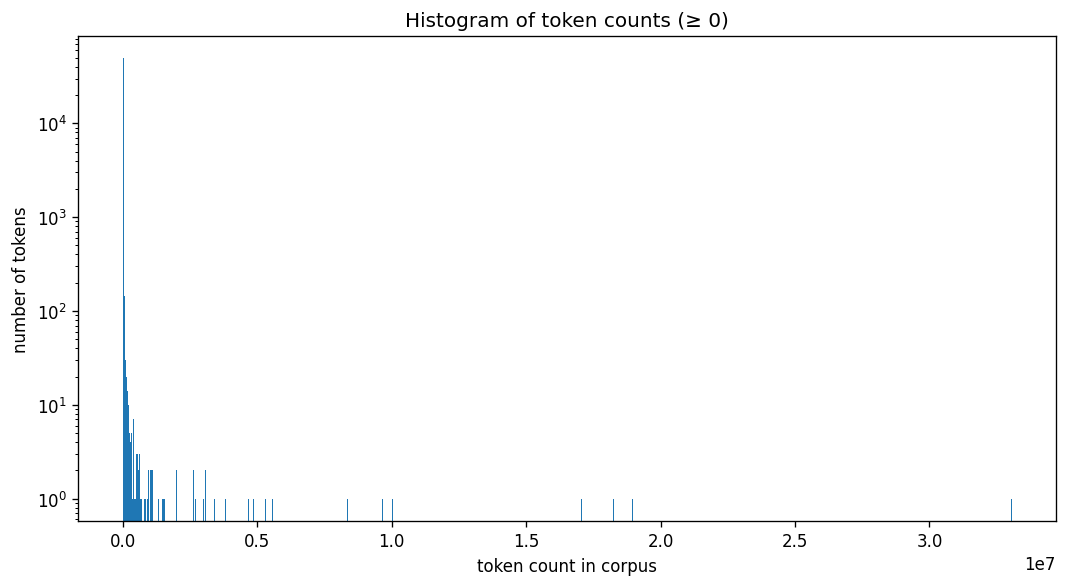

🖼  Saved histogram → results_token_counts/bpe_exact_ll-token_count_hist.png

Lowest 10 by count:
         0  65210
         0  81594
         0  89437
         0  ========================================================================
         0  ========================================================================*
         0  AAFL
         0  AASB
         0  ABETH
         0  ACMLA
         0  ACTIX

Highest 10 by count:
   5316472  Ġthe
   5567713  d
   8352738  r
   9679823  o
  10031060  i
  13759621  a
  17074780  t
  18276478  e
  18945151  s
  33056545  Ġ


In [12]:
# --- Single cell: count token usage with a trained tokenizer.json and plot a histogram ---

import os, json, math
from pathlib import Path
from typing import Iterable, Optional, List, Dict

# ============================
# ========= CONFIG ===========
# ============================
TOKENIZER_JSON = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_exact_ll/bpe_exact_ll-tokenizer.json"
TEXT_PATH      = "/Users/ahmetcanyavuz/Developer/tokenizers/fineweb_data/fineweb_en_sentences.txt"
OUTPUT_DIR     = "./results_token_counts"

# Limits for faster runs (set to None to use all)
MAX_LINES  = None         # e.g. 100_000
BATCH_SIZE = 256

# Histogram options
EXCLUDE_ZERO_COUNTS = False   # many tokens never appear; excluding zeros makes the plot readable
LOG_Y               = True   # log-scale Y axis
HIST_BINS           = 1000
# ============================

import numpy as np
import matplotlib.pyplot as plt

from tokenizers import Tokenizer

try:
    from tqdm import tqdm
except Exception:
    def tqdm(x, **k): return x

# ---------- helpers ----------
def ensure_dir(p: str | Path):
    Path(p).mkdir(parents=True, exist_ok=True)

def iter_lines(path: str | Path, limit: Optional[int] = None) -> Iterable[str]:
    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.rstrip("\n")
            if not s:
                continue
            yield s
            n += 1
            if limit is not None and n >= limit:
                break

# ---------- load tokenizer ----------
tok = Tokenizer.from_file(str(TOKENIZER_JSON))
vocab_map: Dict[str, int] = tok.get_vocab()   # token -> id (includes added tokens)
# Build id -> token
id_to_token: Dict[int, str] = {i: t for t, i in vocab_map.items()}
max_id = max(id_to_token) if id_to_token else -1

# If ids are not dense (should be dense, but be robust), size by max_id+1
size = max_id + 1
counts = np.zeros(size, dtype=np.int64)

print(f"Loaded tokenizer: vocab={len(vocab_map):,}, id-range=[0..{max_id}]")
print(f"Tokenizing text from: {TEXT_PATH}")

# ---------- count ----------
batch: List[str] = []
total_lines = 0
for s in iter_lines(TEXT_PATH, limit=MAX_LINES):
    batch.append(s)
    if len(batch) >= BATCH_SIZE:
        encs = tok.encode_batch(batch, add_special_tokens=False)
        for e in encs:
            for tid in e.ids:
                if 0 <= tid < size:
                    counts[tid] += 1
        total_lines += len(batch)
        batch.clear()
# flush
if batch:
    encs = tok.encode_batch(batch, add_special_tokens=False)
    for e in encs:
        for tid in e.ids:
            if 0 <= tid < size:
                counts[tid] += 1
    total_lines += len(batch)

print(f"Counted over {total_lines:,} lines.")

# ---------- map to token strings & sort ascending ----------
pairs: List[tuple[str, int]] = []
missing = 0
for tid, c in enumerate(counts.tolist()):
    tok_str = id_to_token.get(tid)
    if tok_str is None:
        missing += 1
        continue
    pairs.append((tok_str, int(c)))

if missing:
    print(f"⚠️  {missing} ids had no token string in vocab (skipped).")

# Sort by increasing count
pairs.sort(key=lambda x: (x[1], x[0]))

# ---------- save JSON (as list of [token, count] to preserve order) ----------
ensure_dir(OUTPUT_DIR)
base = Path(TOKENIZER_JSON).stem.replace("-tokenizer", "")
out_json = Path(OUTPUT_DIR) / f"{base}-token_counts_sorted.json"

with open(out_json, "w", encoding="utf-8") as f:
    json.dump([[t, c] for (t, c) in pairs], f, ensure_ascii=False, indent=2)

print(f"💾 Saved sorted token counts → {out_json}")

# ---------- histogram ----------
vals = np.array([c for (_, c) in pairs], dtype=np.int64)
if EXCLUDE_ZERO_COUNTS:
    vals = vals[vals > 0]

fig = plt.figure(figsize=(9, 5), dpi=120)
plt.hist(vals, bins=HIST_BINS)
plt.xlabel("token count in corpus")
plt.ylabel("number of tokens")
ttl = f"Histogram of token counts ({'>' if EXCLUDE_ZERO_COUNTS else '≥'} 0)"
plt.title(ttl)
if LOG_Y:
    plt.yscale("log")
plt.tight_layout()
out_png = Path(OUTPUT_DIR) / f"{base}-token_count_hist.png"
fig.savefig(out_png)
plt.show()
print(f"🖼  Saved histogram → {out_png}")

# ---------- quick peek ----------
print("\nLowest 10 by count:")
for t, c in pairs[:10]:
    print(f"  {c:>8}  {t}")

print("\nHighest 10 by count:")
for t, c in pairs[-10:]:
    print(f"  {c:>8}  {t}")